<a href="https://colab.research.google.com/github/Blenkzx/LINGUAGENS-DE-PROGRAMA-O/blob/main/matplotlib1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)

### Parte 1: Gráficos Essenciais e Personalização (Básico)

#### 1. Gráfico de linha do faturamento mensal total

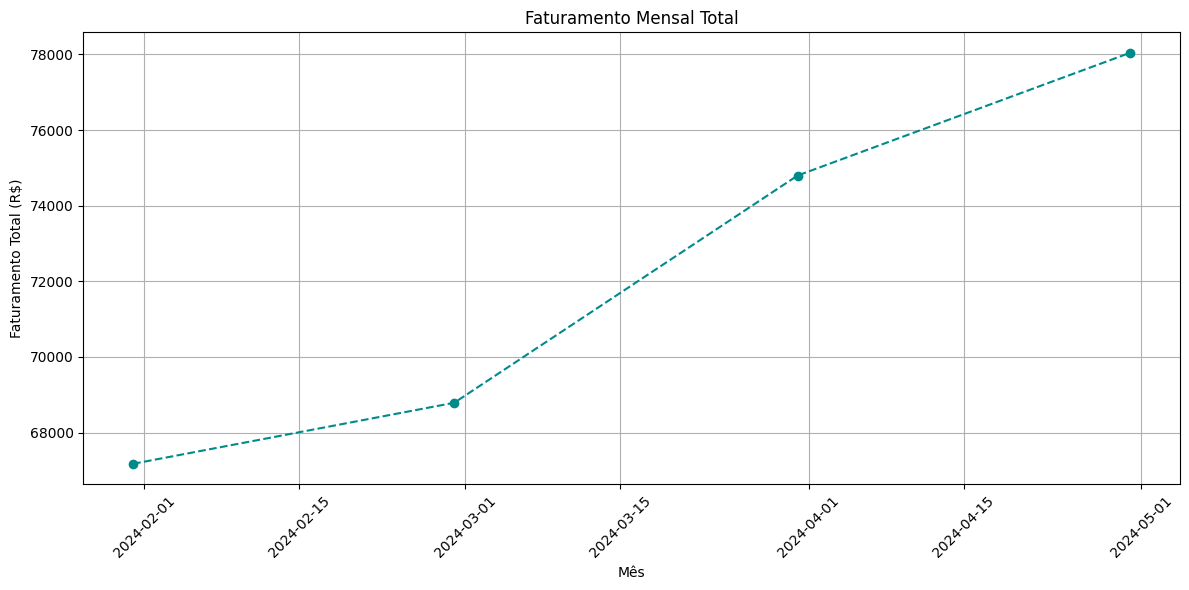

In [4]:
df['data'] = pd.to_datetime(df['data'])
df_mensal = df.set_index('data').resample('ME')['valor_venda'].sum()

plt.figure(figsize=(12, 6))
plt.plot(df_mensal.index, df_mensal.values, marker='o', linestyle='--', color='darkcyan')
plt.grid(True)
plt.xlabel('Mês')
plt.ylabel('Faturamento Total (R$)')
plt.title('Faturamento Mensal Total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 2. Gráfico de barras com o total de vendas por categoria

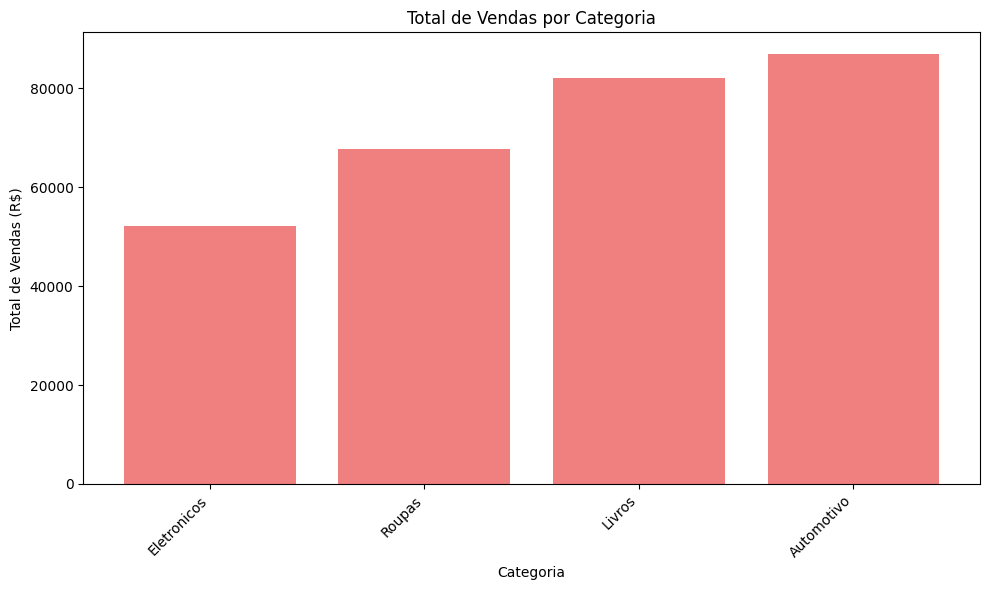

In [5]:
vendas_por_categoria = df.groupby('categoria')['valor_venda'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.bar(vendas_por_categoria.index, vendas_por_categoria.values, color='lightcoral')
plt.xlabel('Categoria')
plt.ylabel('Total de Vendas (R$)')
plt.title('Total de Vendas por Categoria')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 3. Histograma da coluna `valor`

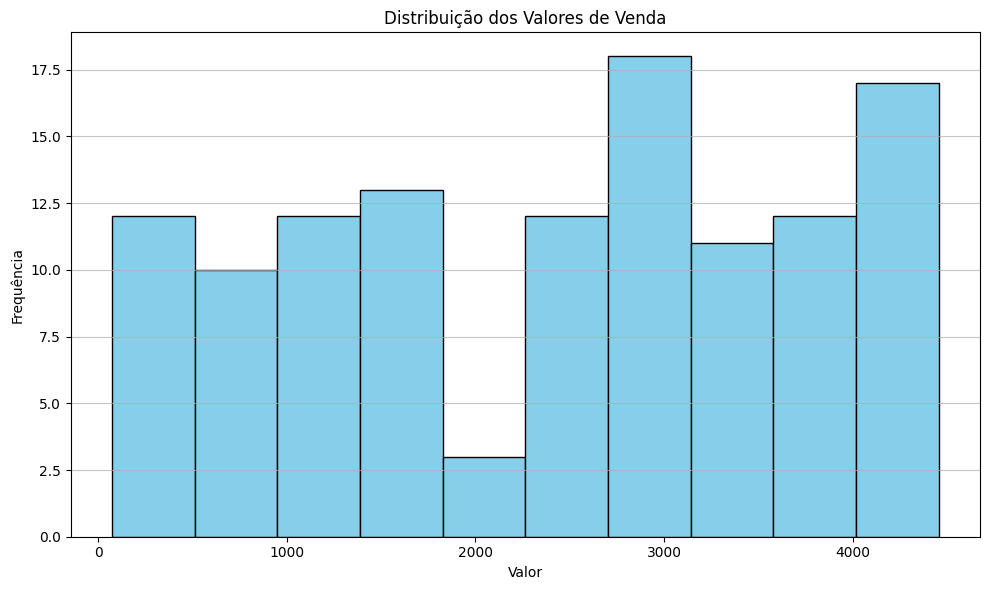

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df['valor'], bins=10, edgecolor='black', color='skyblue')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.title('Distribuição dos Valores de Venda')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Parte 2: API Orientada a Objetos e Eixos Múltiplos (Intermediário)

#### 4. Figura com grade 2x1 de subplots (faturamento e quantidade mensal)

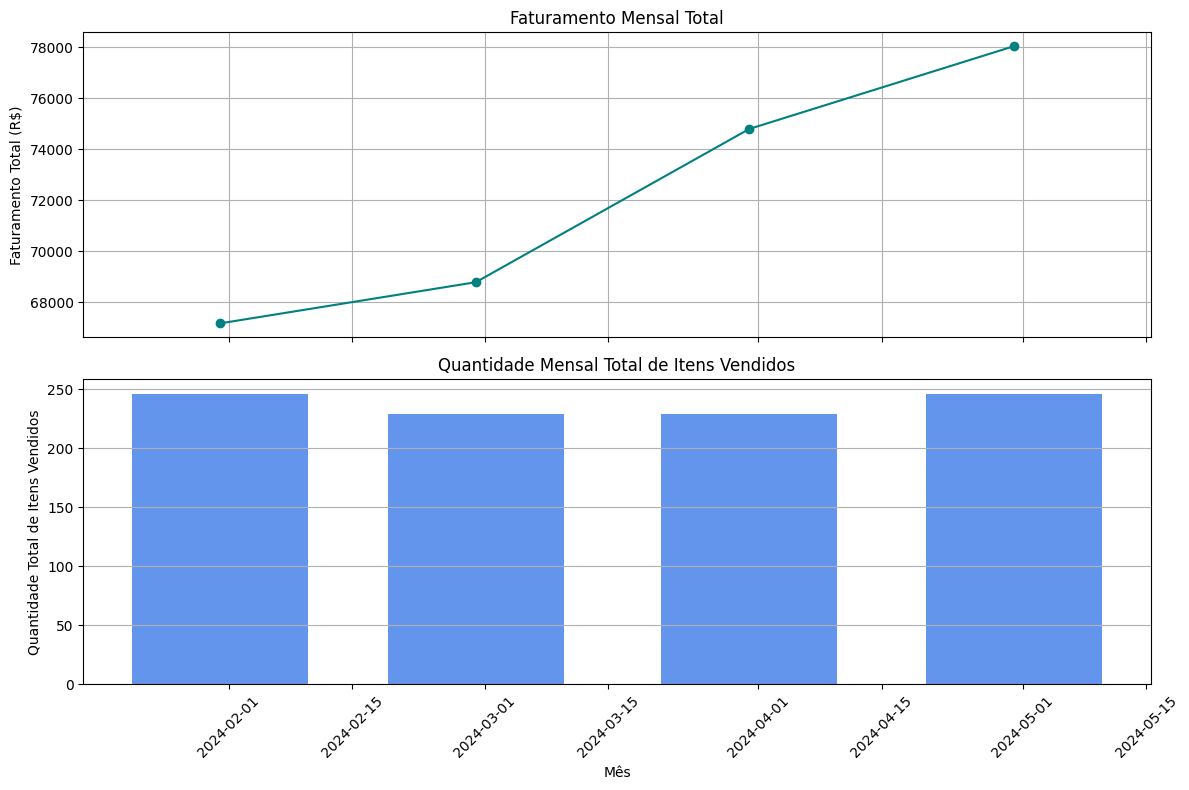

In [7]:
df_mensal_quantidade = df.set_index('data').resample('ME')['quantidade'].sum()

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

ax1.plot(df_mensal.index, df_mensal.values, marker='o', linestyle='-', color='teal')
ax1.set_ylabel('Faturamento Total (R$)')
ax1.set_title('Faturamento Mensal Total')
ax1.grid(True)

ax2.bar(df_mensal_quantidade.index, df_mensal_quantidade.values, color='cornflowerblue', width=pd.Timedelta(days=20))
ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade Total de Itens Vendidos')
ax2.set_title('Quantidade Mensal Total de Itens Vendidos')
ax2.grid(axis='y')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 5. Gráfico com dois eixos Y (valor total vendido e quantidade média de itens por venda mensal)

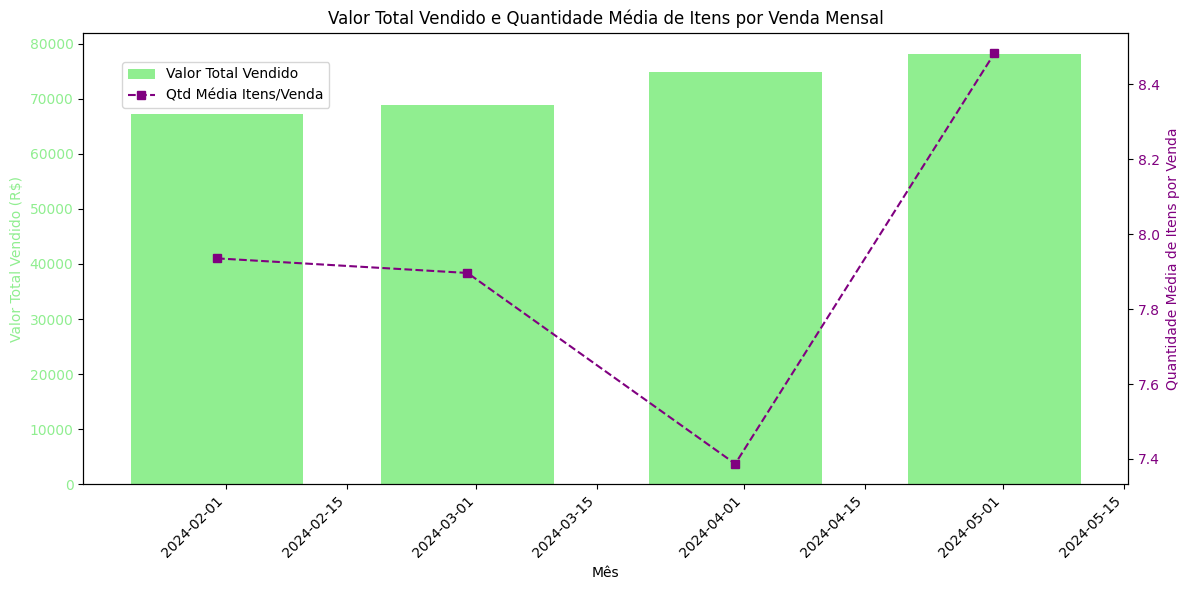

In [8]:
df_mensal_agg = df.set_index('data').resample('ME').agg(
    total_valor=('valor_venda', 'sum'),
    media_quantidade=('quantidade', 'mean') # Média da quantidade por venda no mês
)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo primário (esquerda) - Valor Total Vendido em barras
ax1.bar(df_mensal_agg.index, df_mensal_agg['total_valor'], color='lightgreen', label='Valor Total Vendido', width=pd.Timedelta(days=20))
ax1.set_xlabel('Mês')
ax1.set_ylabel('Valor Total Vendido (R$)', color='lightgreen')
ax1.tick_params(axis='y', labelcolor='lightgreen')

# Eixo secundário (direita) - Quantidade Média de Itens por Venda em linha
ax2 = ax1.twinx()
ax2.plot(df_mensal_agg.index, df_mensal_agg['media_quantidade'], color='purple', marker='s', linestyle='--', label='Qtd Média Itens/Venda')
ax2.set_ylabel('Quantidade Média de Itens por Venda', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

plt.title('Valor Total Vendido e Quantidade Média de Itens por Venda Mensal')
fig.autofmt_xdate(rotation=45)
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))
plt.tight_layout()
plt.show()

#### 6. Anotação para o mês de maior faturamento no gráfico de linha mensal

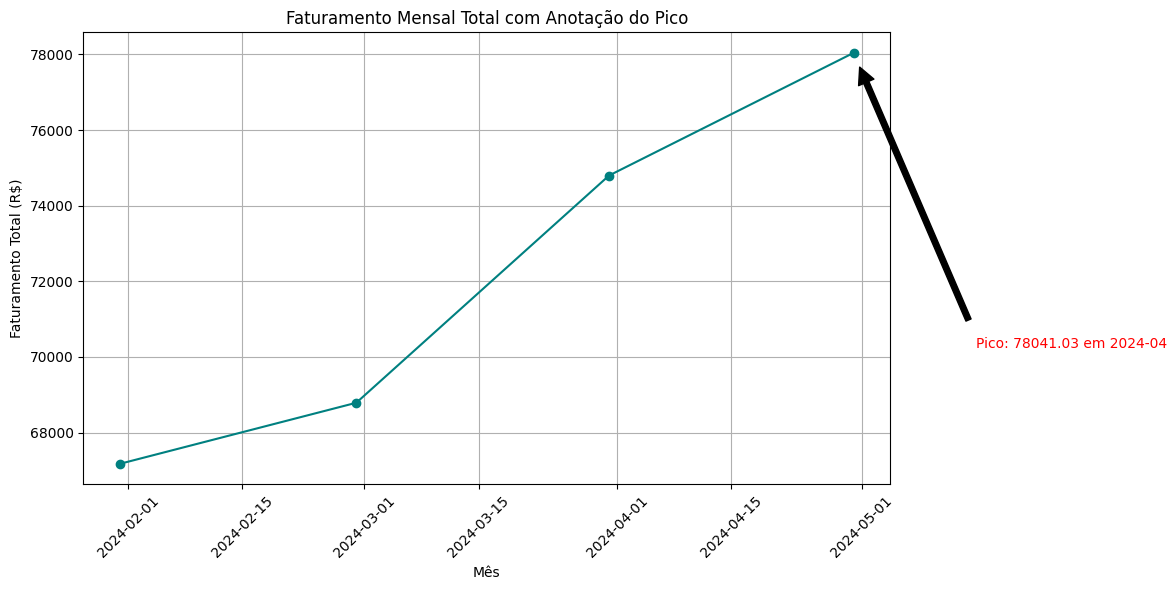

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_mensal.index, df_mensal.values, marker='o', linestyle='-', color='teal')
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento Total (R$)')
ax.set_title('Faturamento Mensal Total com Anotação do Pico')
ax.grid(True)

# Encontrar o mês de maior faturamento
mes_pico_idx = df_mensal.idxmax()
valor_pico = df_mensal.max()

# Adicionar anotação
ax.annotate(
    f'Pico: {valor_pico:.2f} em {mes_pico_idx.strftime('%Y-%m')}', # Texto da anotação
    xy=(mes_pico_idx, valor_pico), # Ponto a ser anotado
    xytext=(mes_pico_idx + pd.DateOffset(days=15), valor_pico * 0.9), # Posição do texto
    arrowprops=dict(facecolor='black', shrink=0.05), # Propriedades da seta
    fontsize=10,
    color='red'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Parte 3: Matriz de Intensidade / Heatmap (Intermediário / Avançado)

#### 7. Tabela dinâmica de valores de venda por categoria e estado

In [10]:
pivot_table = pd.pivot_table(df, values='valor_venda', index='categoria', columns='estado', aggfunc='sum', fill_value=0)
display(pivot_table)

estado,BA,MG,RJ,RS,SP
categoria,,,,,
Automotivo,6992.96,16333.39,26783.38,10122.88,26727.57
Eletronicos,14211.94,13453.06,1154.47,13966.62,9372.80
Livros,4318.03,25667.11,9659.57,19302.59,23104.72
Roupas,26968.88,9876.74,11120.83,4809.04,14856.77


#### 8. Heatmap da matriz e 9. Salvando a figura

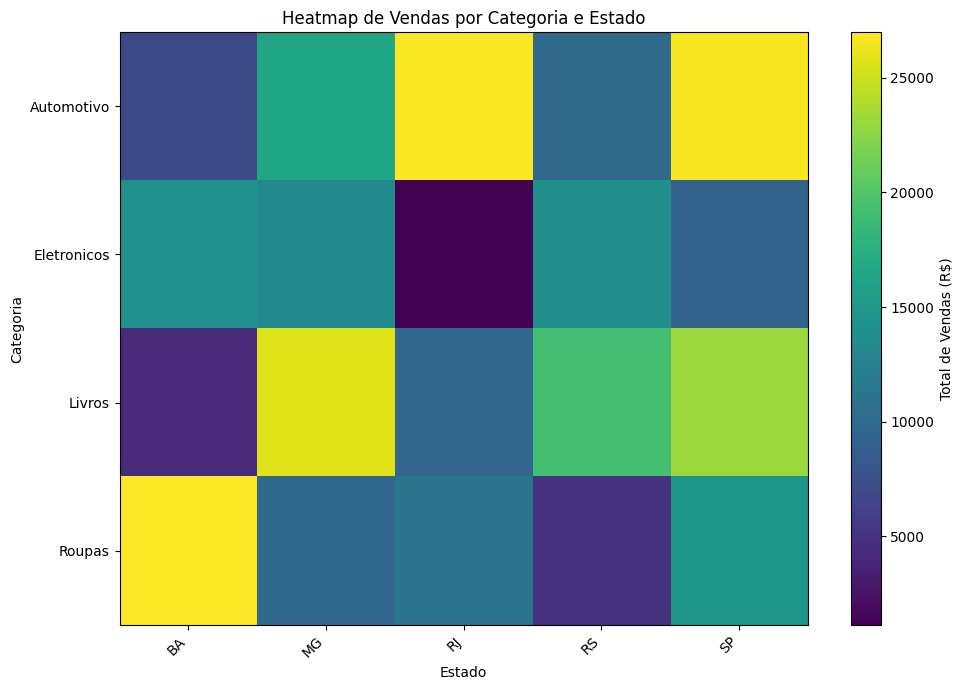

In [11]:
plt.figure(figsize=(10, 7))
plt.imshow(pivot_table, cmap='viridis', aspect='auto')

plt.colorbar(label='Total de Vendas (R$)')

plt.xticks(np.arange(len(pivot_table.columns)), pivot_table.columns, rotation=45, ha='right')
plt.yticks(np.arange(len(pivot_table.index)), pivot_table.index)

plt.xlabel('Estado')
plt.ylabel('Categoria')
plt.title('Heatmap de Vendas por Categoria e Estado')

plt.tight_layout()
plt.savefig('heatmap_vendas.png', dpi=300, bbox_inches='tight')
plt.show()